In [1]:
import pandas as pd
from sqlalchemy import create_engine
import logging
from datetime import timedelta


In [2]:
# Crear conexión con mi db local (contenedor)

user = 'postgres'
password = 'postgres'
host = 'localhost'
port = '5432'
database = 'postgres'


db_url = f'postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}'

engine = create_engine(db_url)



In [3]:
def get_data(country, schema='uber_dev'):
    query = f"""
    select *
    from {schema}.{country}_delivery_trips_info;
    """
    
    try:
        df = pd.read_sql(query, con=engine)
        logging.info(f"Data frame successfully downloaded with the following shape: {df.shape}")
        return df
    except Exception as error:
        logging.error(f"Data frame not successfully downloaded due to the error: {error}")
        raise


In [4]:
df = get_data('mx')
df.head()


,region,territory,country_name,workflow_uuid,driver_uuid,delivery_trip_uuid,courier_flow,restaurant_offered_timestamp_utc,order_final_state_timestamp_local,eater_request_timestamp_local,geo_archetype,merchant_surface,pickup_distance,dropoff_distance,ATD
0,Mexico,South East,Mexico,8c393c94-9282-41a6-a885-7a6e84b470d7,d16e401c-795d-4295-96c0-85ca08ad8c42,715f96aa-0a31-46f6-b856-6ea6f87affad,Motorbike,2025-04-06 19:35:50.000,2025-04-06 13:48:48,2025-04-06 13:35:50,Drive momentum,Tablet,0.643,1.651,12.966667
1,Mexico,South East,Mexico,b156dd16-274f-46d1-ac6f-4c24ca43df69,06299354-23ec-4173-83dc-d6bd32a420e1,ac985454-0e6f-4695-a68b-755c60c2afd7,Motorbike,2025-04-11 22:30:56.000,2025-04-11 16:47:48,2025-04-11 16:30:56,Drive momentum,Tablet,0.812,1.733,16.866667
2,Mexico,South East,Mexico,87a8081b-b735-4daf-8452-3943a9d9ca24,188214a6-3813-44d5-9694-0ae69dfdd7e5,14b274b9-924e-4da7-8803-69558a33559d,Motorbike,2025-04-06 23:15:05.000,2025-04-06 17:34:49,2025-04-06 17:15:05,Drive momentum,Tablet,1.966,1.605,19.733333
3,Mexico,South East,Mexico,78f0e92c-fa45-4215-8c3f-703b8691b6eb,5c7cbb34-116b-4665-aaf3-7f02394c0ff8,ee4faf69-bfff-421a-a163-29dfa4156fc4,Motorbike,2025-04-19 02:38:58.000,2025-04-18 21:21:55,2025-04-18 20:38:58,Drive momentum,Tablet,3.01,4.771,42.950000
4,Mexico,Central,Mexico,e0b2324b-f210-4e6b-82d1-979f9a208967,8b7a3bd8-9cf1-493e-9c64-303db8781045,7870b275-4541-4e09-8fe7-a47e7b506ce4,Motorbike,2025-03-03 03:33:40.000,2025-03-02 22:02:36,2025-03-02 21:33:40,Play offense,Tablet,0.746,4.37,28.933333


In [5]:
df.dtypes

region                                object
territory                             object
country_name                          object
workflow_uuid                         object
driver_uuid                           object
delivery_trip_uuid                    object
courier_flow                          object
restaurant_offered_timestamp_utc      object
order_final_state_timestamp_local     object
eater_request_timestamp_local         object
geo_archetype                         object
merchant_surface                      object
pickup_distance                       object
dropoff_distance                      object
ATD                                  float64
dtype: object

# Data type correction for variables


In [6]:
try:
    df["pickup_distance"] = pd.to_numeric(df["pickup_distance"], errors="coerce")
    df["dropoff_distance"] = pd.to_numeric(df["dropoff_distance"], errors="coerce")

    for timestamp_col in ['restaurant_offered_timestamp_utc', 'order_final_state_timestamp_local', 'eater_request_timestamp_local']:
        df[timestamp_col] = df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors="coerce")
        
    #Since both timestamp variables are in local time, it is convenient for me to change the only UTC to local.
    
    mx_timedelta = 6 # Mexico is -6 hour respect utc time
    df['restaurant_offered_timestamp_local'] = df['restaurant_offered_timestamp_utc'] - timedelta(hours=mx_timedelta)
    df.drop(columns=['restaurant_offered_timestamp_utc'], inplace=True)

except Exception as error:
    logging.error(f"Conversion over columns not successfully due to the error: {error}")

# Summary of variable analysis

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 15 columns):
 #   Column                              Non-Null Count    Dtype         
---  ------                              --------------    -----         
 0   region                              1000000 non-null  object        
 1   territory                           1000000 non-null  object        
 2   country_name                        1000000 non-null  object        
 3   workflow_uuid                       1000000 non-null  object        
 4   driver_uuid                         1000000 non-null  object        
 5   delivery_trip_uuid                  1000000 non-null  object        
 6   courier_flow                        1000000 non-null  object        
 7   order_final_state_timestamp_local   1000000 non-null  datetime64[ns]
 8   eater_request_timestamp_local       1000000 non-null  datetime64[ns]
 9   geo_archetype                       1000000 non-null  object        


In [8]:
# Numerical variables

df.describe().T

,count,mean,std,min,25%,50%,75%,max
pickup_distance,987153.0,1.524548,1.590448,0.0,0.316000,1.131000,2.164000,43.161
dropoff_distance,987153.0,4.110849,3.147828,0.0,1.877000,3.333000,5.556000,123.586
ATD,1000000.0,40.170769,62.754198,0.0,25.116667,33.933333,45.683333,8515.700


In [9]:
# Categorícal variables

df.describe(include='object').T

,count,unique,top,freq
region,1000000,1,Mexico,1000000
territory,1000000,5,Central,376000
country_name,1000000,1,Mexico,1000000
workflow_uuid,1000000,997733,1aed4451-8f91-4fed-9077-5c6b1b9825cf,4
driver_uuid,1000000,91214,\N,12550
delivery_trip_uuid,1000000,999998,4d3c5932-877d-494e-8e5e-4020f95f12c7,2
courier_flow,1000000,8,Motorbike,829312
geo_archetype,1000000,6,Drive momentum,347075
merchant_surface,1000000,5,POS,456767


# Row duplication analysis

In [10]:
duplicateds = df.duplicated(keep=False)

n_duplicates = duplicateds.sum()

if n_duplicates < 10:
    logging.info(f"The following number of exact duplicate rows were found: {n_duplicates}")
else:
    logging.warning(f"There are a large number of exact duplicate rows: {n_duplicates}")
    
dup_trips = df[df.duplicated(subset=["delivery_trip_uuid"], keep=False)]
dup_trips

,region,territory,country_name,workflow_uuid,driver_uuid,delivery_trip_uuid,courier_flow,order_final_state_timestamp_local,eater_request_timestamp_local,geo_archetype,merchant_surface,pickup_distance,dropoff_distance,ATD,restaurant_offered_timestamp_local
10428,Mexico,West,Mexico,1aed4451-8f91-4fed-9077-5c6b1b9825cf,9a959533-3f21-4adc-b85a-f8b8ddbc6b47,a7f2cce0-9e95-478e-9926-4792d04976d5,UberEats,2025-03-01 10:25:24,2025-03-01 09:34:51,Play offense,Other,NaN,NaN,50.55,2025-03-01 09:34:51
10429,Mexico,West,Mexico,1aed4451-8f91-4fed-9077-5c6b1b9825cf,9a959533-3f21-4adc-b85a-f8b8ddbc6b47,a7f2cce0-9e95-478e-9926-4792d04976d5,UberEats,2025-03-01 10:25:24,2025-03-01 09:34:51,Play offense,Other,NaN,NaN,50.55,2025-03-01 09:34:51
11443,Mexico,West,Mexico,1aed4451-8f91-4fed-9077-5c6b1b9825cf,909b716d-6287-49bd-bb13-513460e5cfd1,4d3c5932-877d-494e-8e5e-4020f95f12c7,Motorbike,2025-03-01 10:25:24,2025-03-01 09:34:51,Play offense,Other,0.0,0.0,50.55,2025-03-01 09:34:51
11444,Mexico,West,Mexico,1aed4451-8f91-4fed-9077-5c6b1b9825cf,909b716d-6287-49bd-bb13-513460e5cfd1,4d3c5932-877d-494e-8e5e-4020f95f12c7,Motorbike,2025-03-01 10:25:24,2025-03-01 09:34:51,Play offense,Other,0.0,0.0,50.55,2025-03-01 09:34:51


In [11]:
# Dado que son duplicados exactos sin mayor problema, opto por eliminarlos

df = df.drop_duplicates()

In [12]:
# Validar si hay filas excatas repetidas pero con diferente ATD

dup_trips_without_atd = df[df.drop(columns=['ATD']).duplicated(subset=["delivery_trip_uuid"], keep=False)]
dup_trips_without_atd

,region,territory,country_name,workflow_uuid,driver_uuid,delivery_trip_uuid,courier_flow,order_final_state_timestamp_local,eater_request_timestamp_local,geo_archetype,merchant_surface,pickup_distance,dropoff_distance,ATD,restaurant_offered_timestamp_local


# Removal of columns without contribution

In [13]:
#After checking for duplication using identifiers, I can remove them along with unique cardinality variables. 

df.drop(columns=['region', 'country_name', 'workflow_uuid', 'driver_uuid', 'delivery_trip_uuid'], inplace=True)
df.head()

,territory,courier_flow,order_final_state_timestamp_local,eater_request_timestamp_local,geo_archetype,merchant_surface,pickup_distance,dropoff_distance,ATD,restaurant_offered_timestamp_local
0,South East,Motorbike,2025-04-06 13:48:48,2025-04-06 13:35:50,Drive momentum,Tablet,0.643,1.651,12.966667,2025-04-06 13:35:50
1,South East,Motorbike,2025-04-11 16:47:48,2025-04-11 16:30:56,Drive momentum,Tablet,0.812,1.733,16.866667,2025-04-11 16:30:56
2,South East,Motorbike,2025-04-06 17:34:49,2025-04-06 17:15:05,Drive momentum,Tablet,1.966,1.605,19.733333,2025-04-06 17:15:05
3,South East,Motorbike,2025-04-18 21:21:55,2025-04-18 20:38:58,Drive momentum,Tablet,3.010,4.771,42.950000,2025-04-18 20:38:58
4,Central,Motorbike,2025-03-02 22:02:36,2025-03-02 21:33:40,Play offense,Tablet,0.746,4.370,28.933333,2025-03-02 21:33:40


In [14]:
total_len = len(df)

for column in list(df.columns):
    nulls = 100*df[column].isna().sum() / total_len
    n_values = len(df[df[column]=='\\N'])
    print(f'{column} missing percentage: {nulls}')
    print(f'{column} \\N value percentage: {100*n_values/total_len}')
    print('')



territory missing percentage: 0.0
territory \N value percentage: 0.0

courier_flow missing percentage: 0.0
courier_flow \N value percentage: 0.7549015098030196

order_final_state_timestamp_local missing percentage: 0.0
order_final_state_timestamp_local \N value percentage: 0.0

eater_request_timestamp_local missing percentage: 0.0
eater_request_timestamp_local \N value percentage: 0.0

geo_archetype missing percentage: 0.0
geo_archetype \N value percentage: 0.0

merchant_surface missing percentage: 0.0
merchant_surface \N value percentage: 0.0

pickup_distance missing percentage: 1.2846025692051384
pickup_distance \N value percentage: 0.0

dropoff_distance missing percentage: 1.2846025692051384
dropoff_distance \N value percentage: 0.0

ATD missing percentage: 0.0
ATD \N value percentage: 0.0

restaurant_offered_timestamp_local missing percentage: 0.016500033000066
restaurant_offered_timestamp_local \N value percentage: 0.0



In [15]:
df[df['courier_flow']=='\\N']

,territory,courier_flow,order_final_state_timestamp_local,eater_request_timestamp_local,geo_archetype,merchant_surface,pickup_distance,dropoff_distance,ATD,restaurant_offered_timestamp_local
340,North,\N,2025-03-13 22:28:36,2025-03-13 22:26:51,Play offense,Web/Mobile,NaN,NaN,1.750000,2025-03-13 22:26:52
371,Central,\N,2025-04-21 21:15:47,2025-04-21 21:08:10,Defend CP,POS,0.038,3.469,7.616667,2025-04-21 21:08:10
515,Central,\N,2025-03-14 19:54:25,2025-03-14 19:44:12,Defend CP,Other,NaN,NaN,10.216667,2025-03-14 19:44:12
635,South East,\N,2025-03-02 16:14:17,2025-03-02 16:02:43,Drive momentum,Tablet,NaN,NaN,11.566667,2025-03-02 16:02:43
1163,North,\N,2025-03-08 11:02:03,2025-03-08 11:01:56,Play offense,Unspecified,NaN,NaN,0.116667,2025-03-08 11:01:56
...,...,...,...,...,...,...,...,...,...,...
999532,West,\N,2025-03-18 13:06:26,2025-03-18 13:05:40,Drive momentum,Unspecified,1.658,3.252,0.766667,2025-03-18 13:05:40
999779,South East,\N,2025-04-25 20:24:14,2025-04-25 20:10:58,Play offense,Other,NaN,NaN,13.266667,2025-04-25 20:10:58
999824,North,\N,2025-03-31 15:32:07,2025-03-31 14:58:28,Play offense,Unspecified,NaN,NaN,33.650000,NaT
999871,North,\N,2025-04-04 14:08:47,2025-04-04 13:49:42,Drive momentum,Other,NaN,NaN,19.083333,2025-04-04 14:49:42


In [16]:
df["missing_pickup"] = df["pickup_distance"].isna().astype(int)
df["missing_dropoff"] = df["dropoff_distance"].isna().astype(int)
df["missing_rest_ts"] = df["restaurant_offered_timestamp_local"].isna().astype(int)
df["missing_courier_flow"] = df["courier_flow"]=='\\N'
df["missing_courier_flow"] = df["missing_courier_flow"].astype(int)

df[["missing_pickup", "missing_dropoff", "missing_rest_ts", "missing_courier_flow"]].corr()

,missing_pickup,missing_dropoff,missing_rest_ts,missing_courier_flow
missing_pickup,1.000000,1.000000,0.098093,0.501690
missing_dropoff,1.000000,1.000000,0.098093,0.501690
missing_rest_ts,0.098093,0.098093,1.000000,0.142797
missing_courier_flow,0.501690,0.501690,0.142797,1.000000


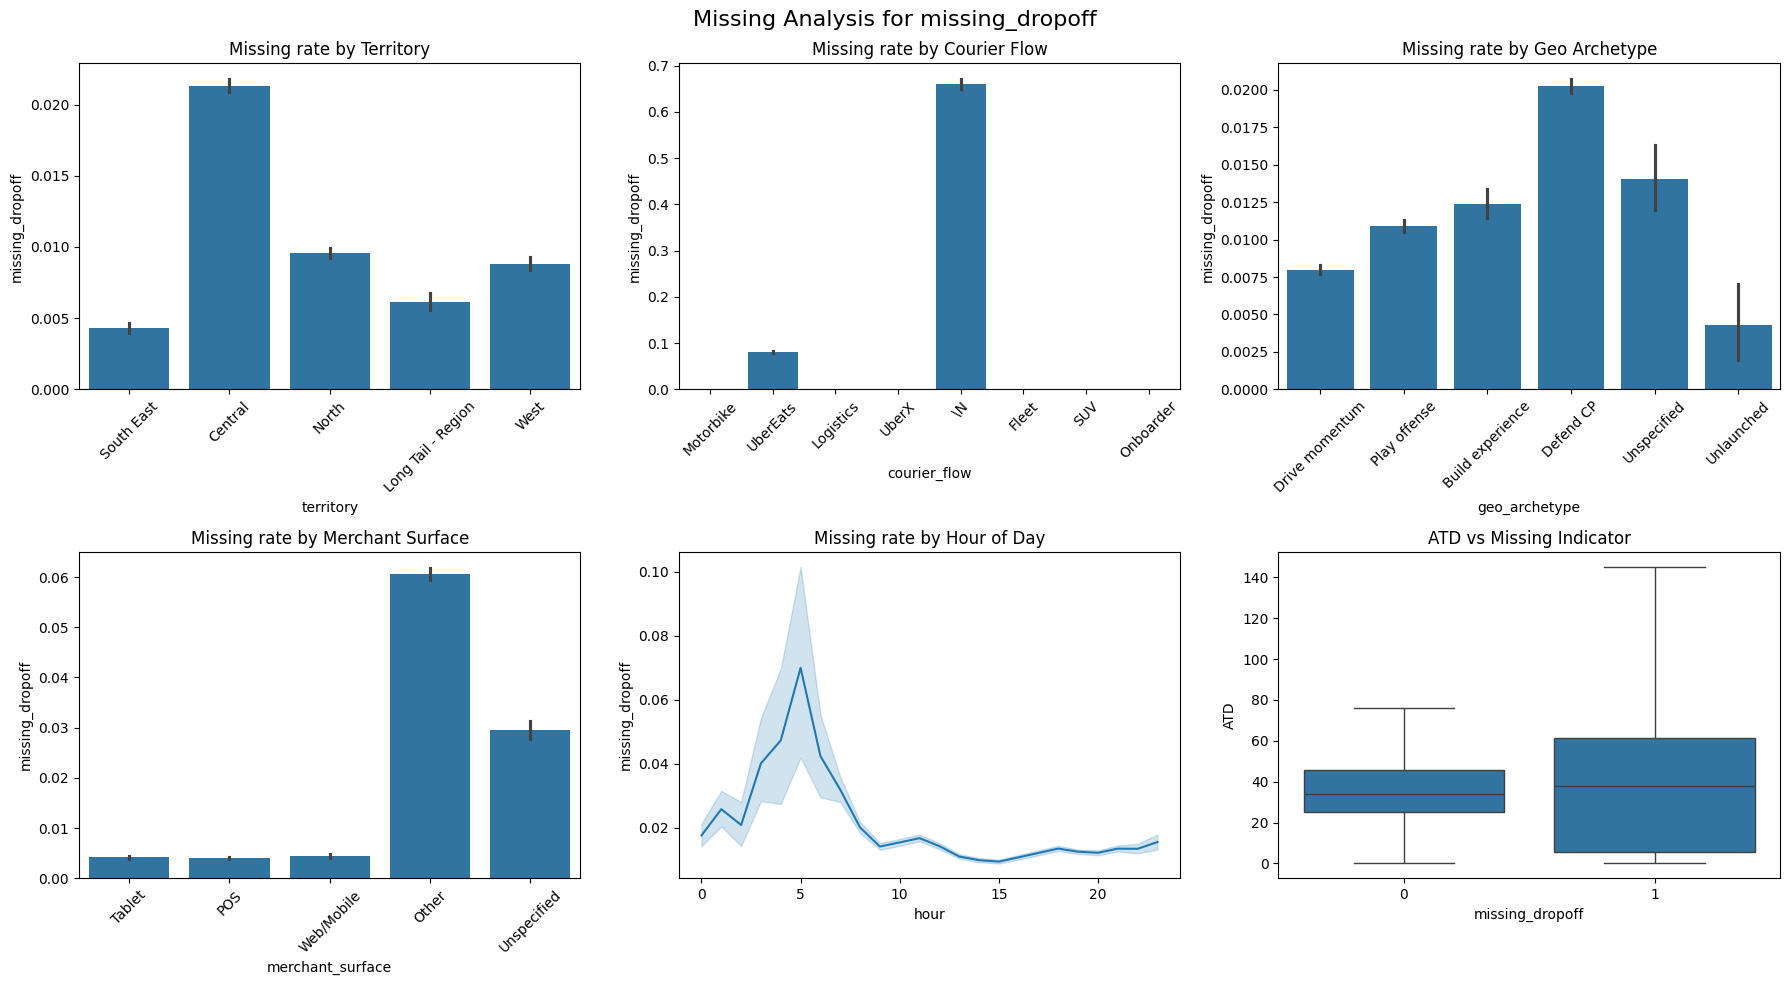

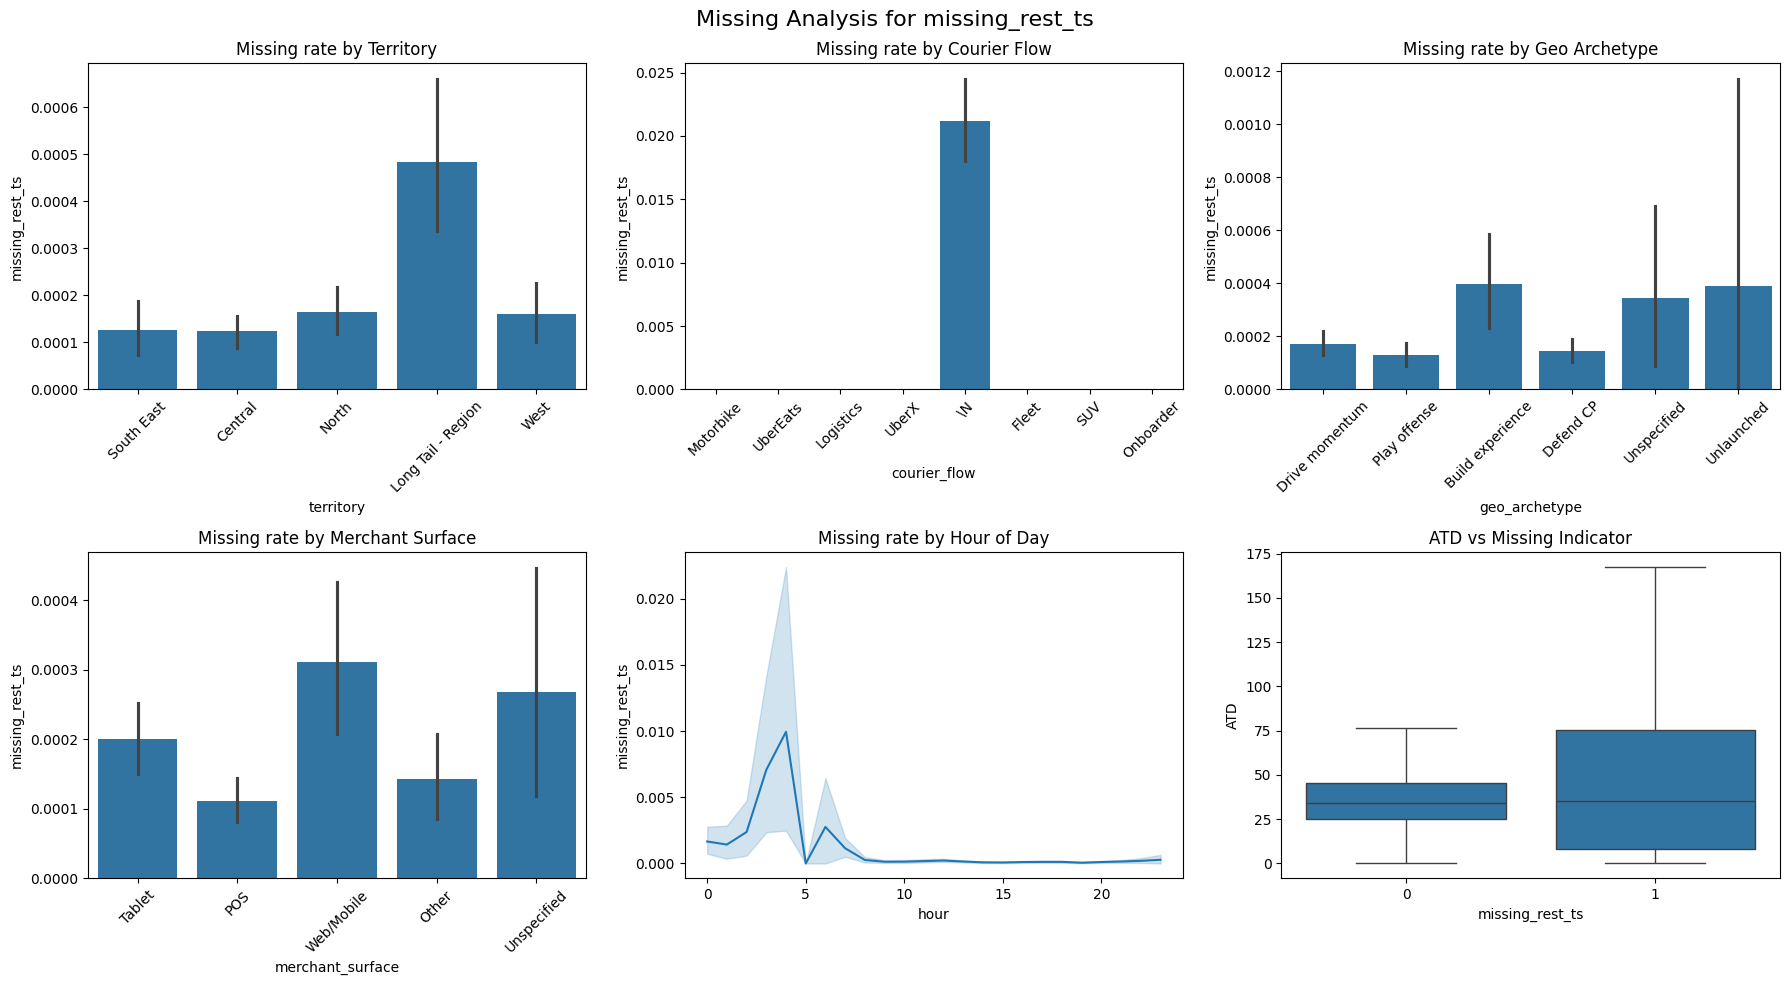

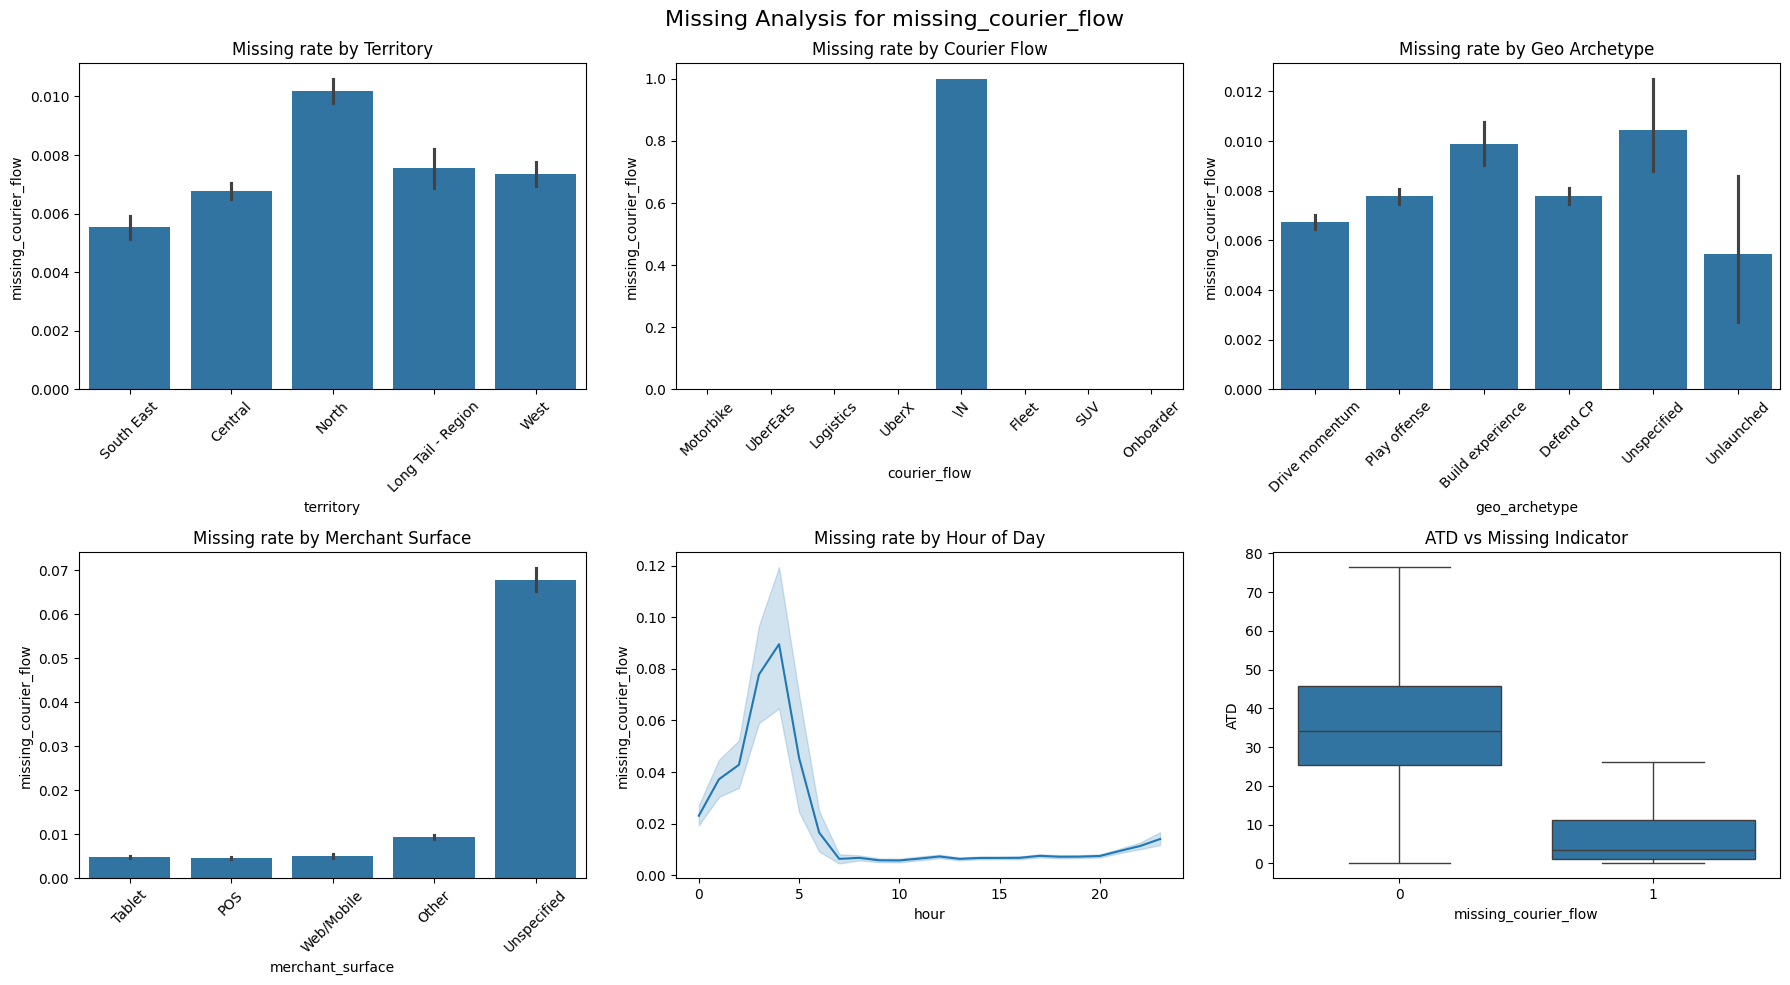

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de variables de missing
missing_cols = [
    #"missing_pickup", Is the same that for missing_dropoff
    "missing_dropoff",
    "missing_rest_ts",
    "missing_courier_flow"
]

# Crear feature de hora
df["hour"] = df["eater_request_timestamp_local"].dt.hour

# Variables categóricas a analizar
cat_cols = ["territory", "courier_flow", "geo_archetype", "merchant_surface"]

for m_col in missing_cols:
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    fig.suptitle(f"Missing Analysis for {m_col}", fontsize=16)
    
    # --- 1. Por territory ---
    sns.barplot(
        data=df,
        x="territory",
        y=m_col,
        estimator="mean",
        ax=axes[0]
    )
    axes[0].set_title("Missing rate by Territory")
    axes[0].tick_params(axis='x', rotation=45)
    
    # --- 2. Por courier_flow ---
    sns.barplot(
        data=df,
        x="courier_flow",
        y=m_col,
        estimator="mean",
        ax=axes[1]
    )
    axes[1].set_title("Missing rate by Courier Flow")
    axes[1].tick_params(axis='x', rotation=45)
    
    # --- 3. Por geo_archetype ---
    sns.barplot(
        data=df,
        x="geo_archetype",
        y=m_col,
        estimator="mean",
        ax=axes[2]
    )
    axes[2].set_title("Missing rate by Geo Archetype")
    axes[2].tick_params(axis='x', rotation=45)
    
    # --- 4. Por merchant_surface ---
    sns.barplot(
        data=df,
        x="merchant_surface",
        y=m_col,
        estimator="mean",
        ax=axes[3]
    )
    axes[3].set_title("Missing rate by Merchant Surface")
    axes[3].tick_params(axis='x', rotation=45)
    
    # --- 5. Por hora del día ---
    sns.lineplot(
        data=df,
        x="hour",
        y=m_col,
        estimator="mean",
        ax=axes[4]
    )
    axes[4].set_title("Missing rate by Hour of Day")
    
    # --- 6. Distribución vs ATD ---
    sns.boxplot(
        data=df,
        x=m_col,
        y="ATD",
        ax=axes[5],
        showfliers=False
    )
    axes[5].set_title("ATD vs Missing Indicator")
    
    plt.tight_layout()
    plt.show()

In [18]:
# Flag of the missing
df["missing_distance"] = df["pickup_distance"].isna().astype(int)

# Imputacion segregada por territorio
df["pickup_distance"] = df.groupby("territory")["pickup_distance"]\
    .transform(lambda x: x.fillna(x.median()))

df["dropoff_distance"] = df.groupby("territory")["dropoff_distance"]\
    .transform(lambda x: x.fillna(x.median()))

# Re name
df["courier_flow"] = df["courier_flow"].replace("\\N", "Unespecified")

# Drop 
df = df.dropna(subset=["restaurant_offered_timestamp_local"])
df.drop(columns=['missing_dropoff', 'missing_pickup', 'missing_rest_ts', 'missing_courier_flow', 'hour'],
       inplace=True)

df.head()

,territory,courier_flow,order_final_state_timestamp_local,eater_request_timestamp_local,geo_archetype,merchant_surface,pickup_distance,dropoff_distance,ATD,restaurant_offered_timestamp_local,missing_distance
0,South East,Motorbike,2025-04-06 13:48:48,2025-04-06 13:35:50,Drive momentum,Tablet,0.643,1.651,12.966667,2025-04-06 13:35:50,0
1,South East,Motorbike,2025-04-11 16:47:48,2025-04-11 16:30:56,Drive momentum,Tablet,0.812,1.733,16.866667,2025-04-11 16:30:56,0
2,South East,Motorbike,2025-04-06 17:34:49,2025-04-06 17:15:05,Drive momentum,Tablet,1.966,1.605,19.733333,2025-04-06 17:15:05,0
3,South East,Motorbike,2025-04-18 21:21:55,2025-04-18 20:38:58,Drive momentum,Tablet,3.010,4.771,42.950000,2025-04-18 20:38:58,0
4,Central,Motorbike,2025-03-02 22:02:36,2025-03-02 21:33:40,Play offense,Tablet,0.746,4.370,28.933333,2025-03-02 21:33:40,0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 999833 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column                              Non-Null Count   Dtype         
---  ------                              --------------   -----         
 0   territory                           999833 non-null  object        
 1   courier_flow                        999833 non-null  object        
 2   order_final_state_timestamp_local   999833 non-null  datetime64[ns]
 3   eater_request_timestamp_local       999833 non-null  datetime64[ns]
 4   geo_archetype                       999833 non-null  object        
 5   merchant_surface                    999833 non-null  object        
 6   pickup_distance                     999833 non-null  float64       
 7   dropoff_distance                    999833 non-null  float64       
 8   ATD                                 999833 non-null  float64       
 9   restaurant_offered_timestamp_local  999833 non-null  datetime64[ns]
 10  missing_

# Additional validations according to business logic

In [20]:
df[df["ATD"] < 0]


,territory,courier_flow,order_final_state_timestamp_local,eater_request_timestamp_local,geo_archetype,merchant_surface,pickup_distance,dropoff_distance,ATD,restaurant_offered_timestamp_local,missing_distance


In [44]:
# Incongruencias

df[df['restaurant_offered_timestamp_local']>df['order_final_state_timestamp_local']][['eater_request_timestamp_local', 
                                               'restaurant_offered_timestamp_local',
                                               'order_final_state_timestamp_local',
                                               'ATD'
                                              ]]

,eater_request_timestamp_local,restaurant_offered_timestamp_local,order_final_state_timestamp_local,ATD
6,2025-04-27 14:08:22,2025-04-27 15:08:22,2025-04-27 14:36:34,28.200000
12,2025-03-30 19:28:41,2025-03-30 20:28:42,2025-03-30 20:08:24,39.716667
27,2025-04-12 12:09:48,2025-04-12 13:09:49,2025-04-12 12:39:32,29.733333
37,2025-03-07 18:49:02,2025-03-07 20:49:02,2025-03-07 19:32:29,43.450000
40,2025-03-21 20:17:19,2025-03-21 21:17:19,2025-03-21 20:36:55,19.600000
...,...,...,...,...
999967,2025-03-30 01:03:43,2025-03-30 02:03:43,2025-03-30 01:48:30,44.783333
999969,2025-04-01 06:59:08,2025-04-01 07:59:09,2025-04-01 07:34:59,35.850000
999988,2025-03-30 15:58:51,2025-03-30 16:58:51,2025-03-30 16:55:09,56.300000
999992,2025-03-14 12:57:53,2025-03-14 13:57:53,2025-03-14 13:49:45,51.866667


In [45]:
# Incongruencias

df[df['eater_request_timestamp_local']>df['order_final_state_timestamp_local']][['eater_request_timestamp_local', 
                                               'restaurant_offered_timestamp_local',
                                               'order_final_state_timestamp_local',
                                               'ATD'
                                              ]]

,eater_request_timestamp_local,restaurant_offered_timestamp_local,order_final_state_timestamp_local,ATD


In [38]:
df["diff_final_minus_offered"] = (
    df["order_final_state_timestamp_local"] - 
    df["restaurant_offered_timestamp_local"]
).dt.total_seconds() / 60

df["diff_offered_minus_final"] = (
    df["restaurant_offered_timestamp_local"] - 
    df["order_final_state_timestamp_local"]
).dt.total_seconds() / 60

df["diff_final_minus_request"] = (
    df["order_final_state_timestamp_local"] - 
    df["eater_request_timestamp_local"]
).dt.total_seconds() / 60

df["diff_offered_minus_request"] = (
    df["restaurant_offered_timestamp_local"] - 
    df["eater_request_timestamp_local"]
).dt.total_seconds() / 60

df["diff_request_minus_offered"] = (
    df["eater_request_timestamp_local"] - 
    df["restaurant_offered_timestamp_local"]
).dt.total_seconds() / 60

df["diff_request_minus_final"] = (
    df["eater_request_timestamp_local"] - 
    df["order_final_state_timestamp_local"]
).dt.total_seconds() / 60


for column in [
    'diff_final_minus_offered',
    'diff_offered_minus_final',
    'diff_final_minus_request',
    'diff_offered_minus_request'
]:
    diff = (df[column] - df["ATD"]).abs()
    match_pct = (diff < 0.01).mean() * 100
    print(f"{column}: {match_pct:.2f}% match")
                

diff_final_minus_offered: 67.92% match
diff_offered_minus_final: 0.00% match
diff_final_minus_request: 100.00% match
diff_offered_minus_request: 0.00% match


In [42]:
# ATD is always order_final_state_timestamp_local - eater_request_timestamp_local
# Sometimes restaurant_offered_timestamp_local == eater_request_timestamp_local

df[df['diff_final_minus_offered']==df['ATD']][['eater_request_timestamp_local', 
                                               'restaurant_offered_timestamp_local',
                                               'order_final_state_timestamp_local',
                                               'ATD'
                                              ]]

,eater_request_timestamp_local,restaurant_offered_timestamp_local,order_final_state_timestamp_local,ATD
1,2025-04-11 16:30:56,2025-04-11 16:30:56,2025-04-11 16:47:48,16.866667
3,2025-04-18 20:38:58,2025-04-18 20:38:58,2025-04-18 21:21:55,42.950000
4,2025-03-02 21:33:40,2025-03-02 21:33:40,2025-03-02 22:02:36,28.933333
5,2025-03-08 15:52:40,2025-03-08 15:52:40,2025-03-08 16:14:25,21.750000
8,2025-03-16 21:51:03,2025-03-16 21:51:03,2025-03-16 22:36:37,45.566667
...,...,...,...,...
999989,2025-03-13 22:16:54,2025-03-13 22:16:54,2025-03-13 22:41:40,24.766667
999991,2025-04-22 15:26:12,2025-04-22 15:26:12,2025-04-22 16:08:16,42.066667
999993,2025-03-08 21:56:01,2025-03-08 21:56:01,2025-03-08 22:47:35,51.566667
999994,2025-04-03 21:49:41,2025-04-03 21:49:41,2025-04-03 22:10:07,20.433333


## 🔍 Inconsistent Timestamp Cases: `offered > final`

Some rows show `restaurant_offered_timestamp_local > order_final_state_timestamp_local`, which is not logically consistent under a standard flow.

### Possible Causes

* **Early user cancellation**: Order is canceled before being offered to the restaurant.
* **Asynchronous logging**: Events are recorded out of order due to system latency.
* **Re-dispatch attempts**: Late “offered” events from retry logic.
* **Semantic mismatch**: `offered` may not represent the first actual offer.
* **Data quality issues**: Pipeline errors, joins, or delayed ingestion.

###  Implications

* `restaurant_offered_timestamp` is **not always reliable**
* Can introduce noise in derived features like delivery time

### Recommendation

Using conditionally:

```python
df["valid_offered"] = (
    df["restaurant_offered_timestamp_local"] <= 
    df["order_final_state_timestamp_local"]
)
```

### Conclusion

These cases likely reflect **system behavior rather than pure data errors**, and should be handled as conditional signals instead of being blindly removed.


In [46]:
import numpy as np

# Flag 1: offered == request
df["offered_equals_request"] = (
    df["restaurant_offered_timestamp_local"] == 
    df["eater_request_timestamp_local"]
).astype(int)

# Flag 2: inconsistencia temporal (offered > final)
df["offered_after_final"] = (
    df["restaurant_offered_timestamp_local"] > 
    df["order_final_state_timestamp_local"]
).astype(int)


df[["offered_equals_request", "offered_after_final"]].mean()

offered_equals_request    0.679189
offered_after_final       0.101725
dtype: float64

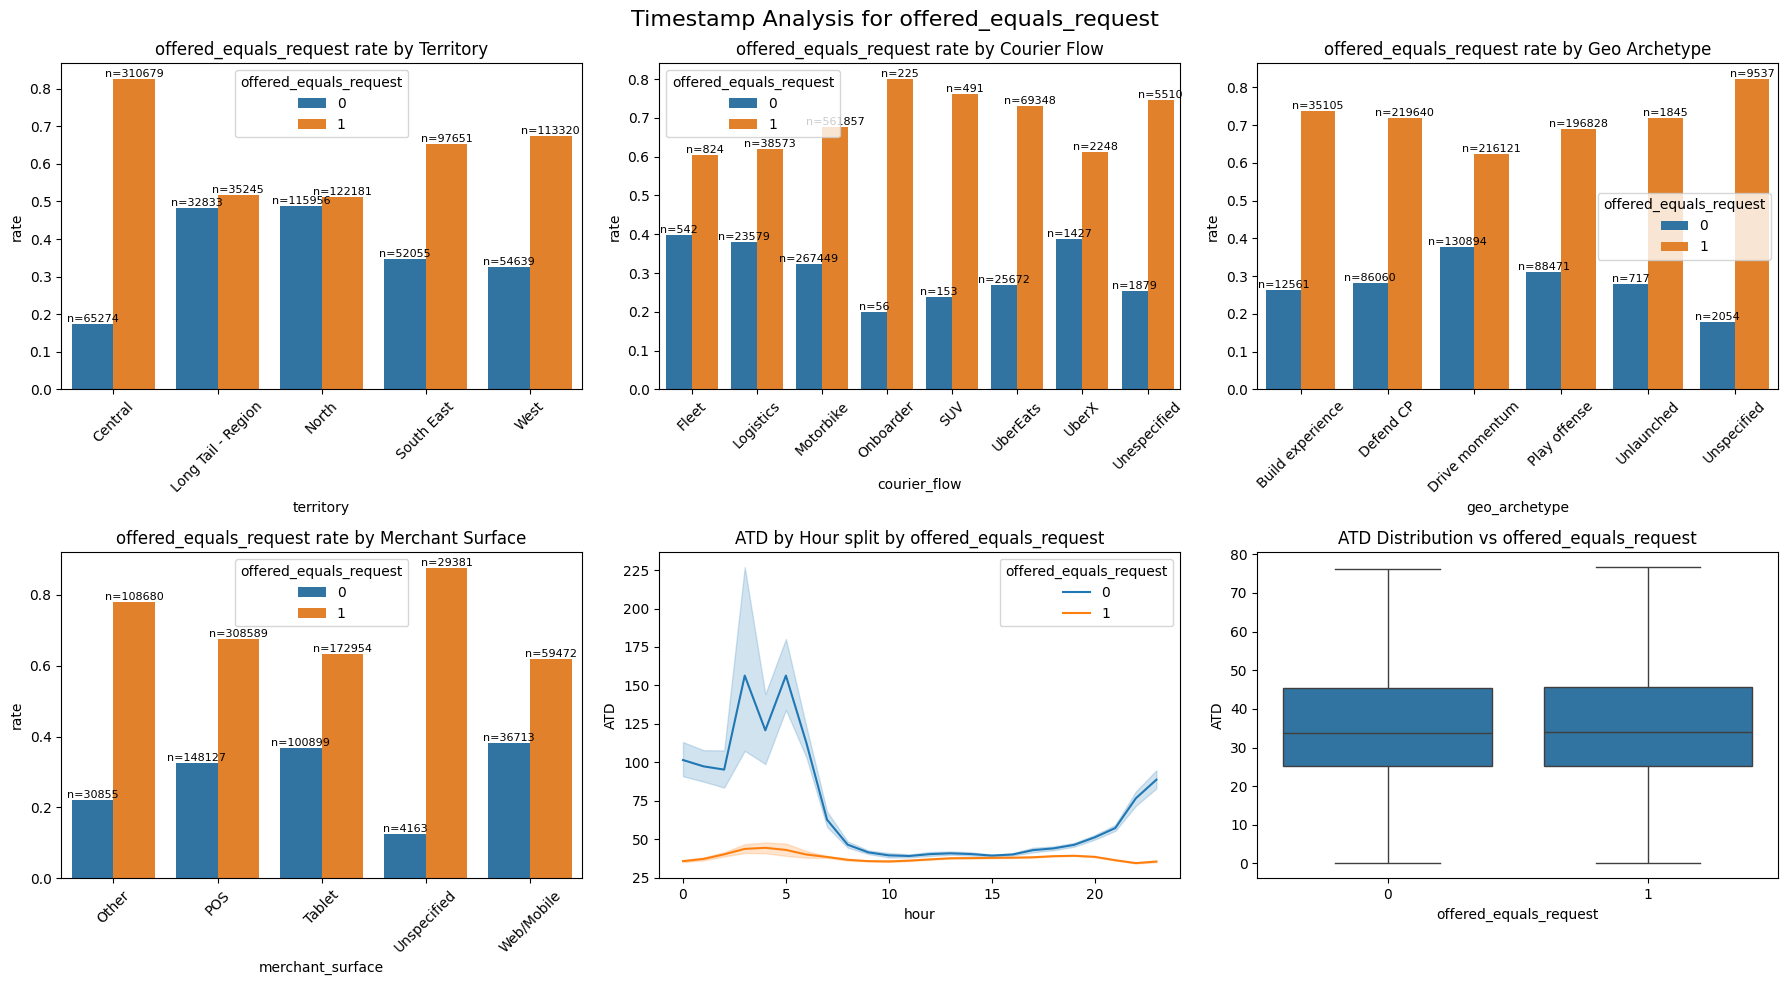

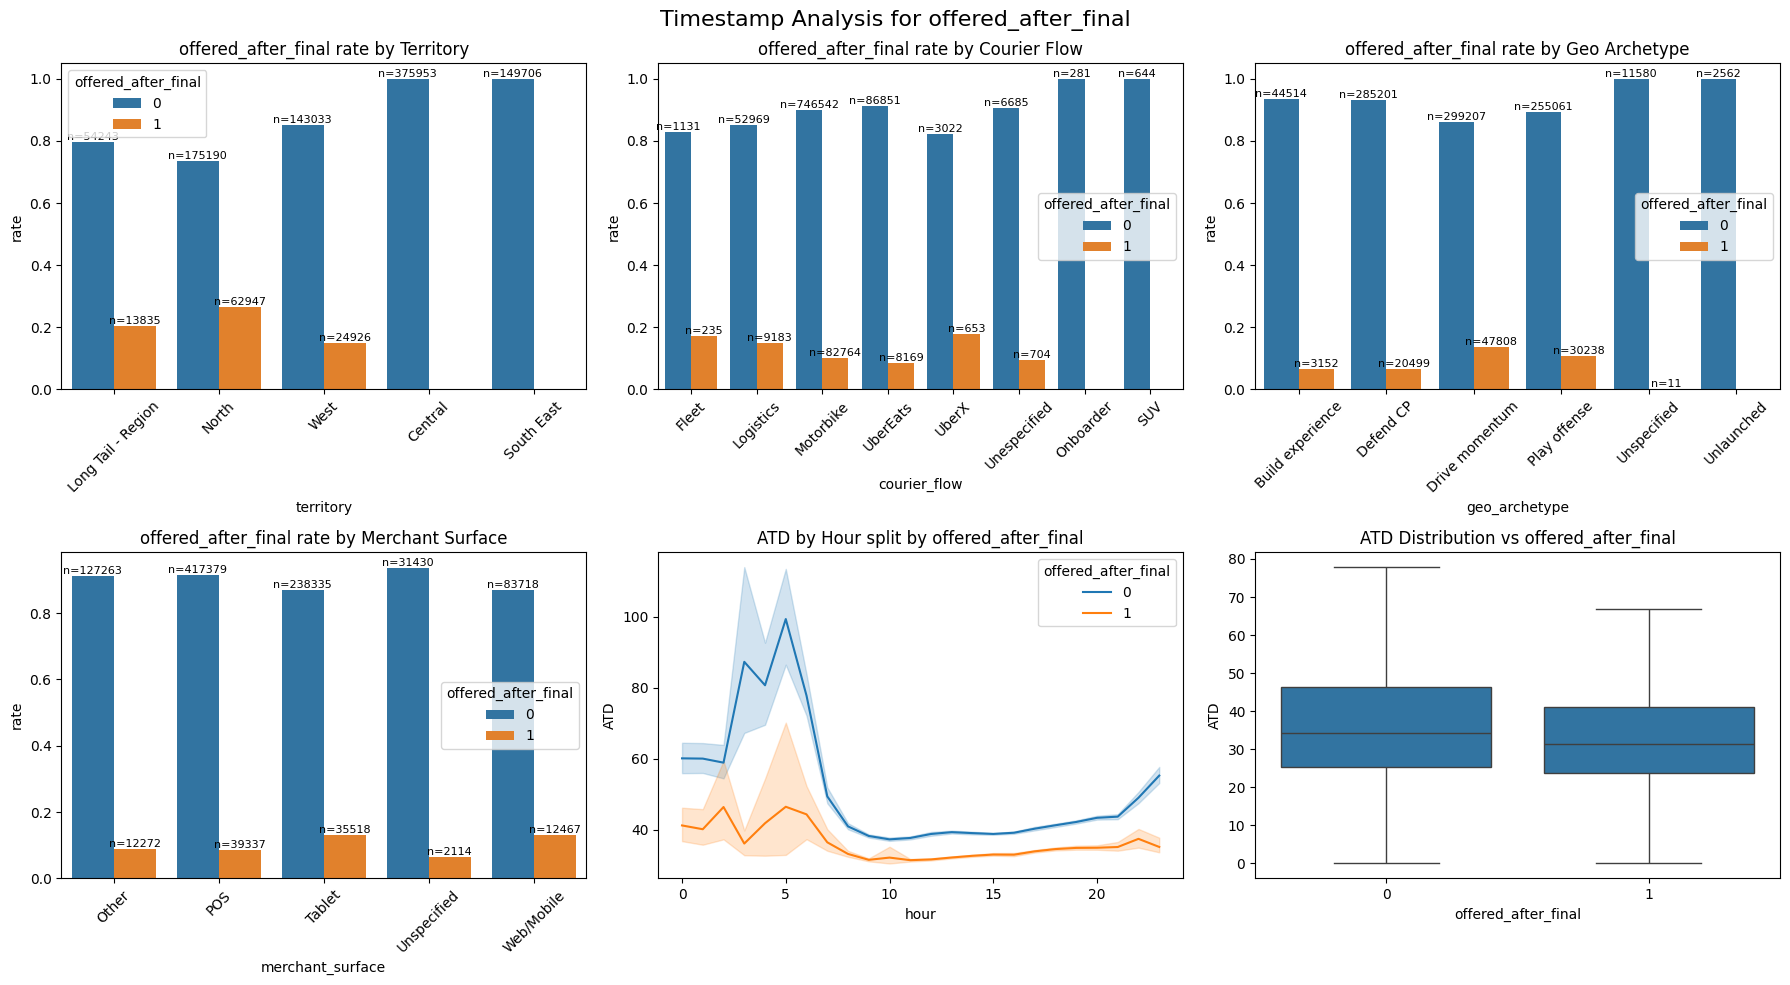


==== offered_equals_request ====
                           count       mean         std       min        25%  \
offered_equals_request                                                         
0                       320757.0  45.719690  105.252118  0.016667  25.133333   
1                       679076.0  37.535692   23.135012  0.000000  25.116667   

                              50%        75%      max  
offered_equals_request                                 
0                       33.850000  45.516667  8515.70  
1                       33.966667  45.750000  4362.65  

==== offered_after_final ====
                        count       mean        std       min        25%  \
offered_after_final                                                        
0                    898125.0  40.913044  65.191818  0.000000  25.283333   
1                    101708.0  33.522146  32.796332  0.016667  23.833333   

                           50%        75%          max  
offered_after_final         

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -----------------------------
# FEATURES
# -----------------------------
df["hour"] = df["eater_request_timestamp_local"].dt.hour

# Flags ya creados:
missing_cols = [
    "offered_equals_request",
    "offered_after_final",
]

cat_cols = ["territory", "courier_flow", "geo_archetype", "merchant_surface"]

# -----------------------------
# HELPER FUNCTION
# -----------------------------
def plot_rate_and_count(data, x, y, ax):
    # Agrupar por categoría + flag
    agg = data.groupby([x, y]).size().reset_index(name="count")
    
    # Total por categoría
    total = data.groupby(x).size().reset_index(name="total")
    
    # Merge para calcular tasa
    agg = agg.merge(total, on=x)
    agg["rate"] = agg["count"] / agg["total"]
    
    # Ordenar categorías
    order = (
        agg.groupby(x)["rate"]
        .mean()
        .sort_values()
        .index
    )
    
    sns.barplot(
        data=agg,
        x=x,
        y="rate",
        hue=y,
        order=order,
        ax=ax
    )
    
    for i, row in agg.iterrows():
        ax.text(
            x=list(order).index(row[x]) + (-0.2 if row[y]==0 else 0.2),
            y=row["rate"],
            s=f'n={int(row["count"])}',
            ha='center',
            va='bottom',
            fontsize=8
        )

# -----------------------------
# MAIN LOOP
# -----------------------------
for m_col in missing_cols:
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    fig.suptitle(f"Timestamp Analysis for {m_col}", fontsize=16)
    
    # 1. Territory
    plot_rate_and_count(df, "territory", m_col, axes[0])
    axes[0].set_title(f"{m_col} rate by Territory")
    axes[0].tick_params(axis='x', rotation=45)
    
    # 2. Courier Flow
    plot_rate_and_count(df, "courier_flow", m_col, axes[1])
    axes[1].set_title(f"{m_col} rate by Courier Flow")
    axes[1].tick_params(axis='x', rotation=45)
    
    # 3. Geo Archetype
    plot_rate_and_count(df, "geo_archetype", m_col, axes[2])
    axes[2].set_title(f"{m_col} rate by Geo Archetype")
    axes[2].tick_params(axis='x', rotation=45)
    
    # 4. Merchant Surface
    plot_rate_and_count(df, "merchant_surface", m_col, axes[3])
    axes[3].set_title(f"{m_col} rate by Merchant Surface")
    axes[3].tick_params(axis='x', rotation=45)
    
    # 5. Hour vs ATD (con separación por flag)
    sns.lineplot(
        data=df,
        x="hour",
        y="ATD",
        hue=m_col,
        estimator="mean",
        ax=axes[4]
    )
    axes[4].set_title(f"ATD by Hour split by {m_col}")
    
    # 6. Distribución ATD (más informativa)
    sns.boxplot(
        data=df,
        x=m_col,
        y="ATD",
        ax=axes[5],
        showfliers=False
    )
    axes[5].set_title(f"ATD Distribution vs {m_col}")
    
    plt.tight_layout()
    plt.show()


for m_col in missing_cols:
    print(f"\n==== {m_col} ====")
    print(df.groupby(m_col)["ATD"].describe())

## Key Insights from Timestamp Analysis



* **~68% of orders are assigned instantly**, representing the system’s optimal operating condition.

* **Delayed dispatch (~22%) is the main source of higher ATD and variability**, likely driven by supply-demand imbalance or operational constraints.

* **Inconsistent cases (~10%) show lower ATD and low variance**, suggesting they correspond to edge cases (e.g., cancellations, truncated flows) rather than normal deliveries.

* **Operational differences exist across segments**:

  * Some territories and courier types show higher delay rates.
  * Merchant surface (e.g., POS vs Web/Mobile) impacts assignment efficiency.

* **Time of day affects performance**, with peak hours showing greater divergence between instant and delayed dispatch.

* **`restaurant_offered_timestamp` is not always reliable**, and should be used conditionally or as a feature with a validity flag.

* **System behavior can be segmented into three regimes**:

  * Instant dispatch (efficient baseline)
  * Delayed dispatch (core optimization opportunity)
  * Inconsistent flows (edge cases / noise)

* **Key modeling implication**:

  * Include dispatch-related features (or proxies) to significantly improve predictive performance.


In [56]:
#1) offered_equals_request No parece tener un patron especifico, de pronto las regiones centrales parecen tener asignacion mas inmediata
#=> No hay columnas que sirvan como identifier para saber si sera asignación inmediata o no

#2) offered_after_final parece estar relacionado con el territory el coourier flow y la geo archetype pero no con la
#hora => podemos asumir que fueron ordenes canceladas e ignorarlas para el entrenamiento


df_clean = df[df["offered_after_final"] == 0]


In [70]:

# -----------------------------
# FLAG ATD = 0
# -----------------------------
df_clean["atd_zero"] = (df_clean["ATD"] == 0).astype(int)

df_clean[df_clean["atd_zero"]==1]

# Solo hay 2 filas por ende despreciables

df_clean = df_clean[df_clean["ATD"] > 0]

df_clean.drop(columns=['diff_final_minus_offered', 'diff_offered_minus_final', 'diff_final_minus_request',
                      'diff_offered_minus_request', 'diff_request_minus_offered', 'diff_request_minus_final',
                      'hour', 'atd_zero', 'offered_after_final'], inplace=True)

df_clean.head()

,territory,courier_flow,order_final_state_timestamp_local,eater_request_timestamp_local,geo_archetype,merchant_surface,pickup_distance,dropoff_distance,ATD,restaurant_offered_timestamp_local,missing_distance,offered_equals_request
0,South East,Motorbike,2025-04-06 13:48:48,2025-04-06 13:35:50,Drive momentum,Tablet,0.643,1.651,12.966667,2025-04-06 13:35:50,0,1
1,South East,Motorbike,2025-04-11 16:47:48,2025-04-11 16:30:56,Drive momentum,Tablet,0.812,1.733,16.866667,2025-04-11 16:30:56,0,1
2,South East,Motorbike,2025-04-06 17:34:49,2025-04-06 17:15:05,Drive momentum,Tablet,1.966,1.605,19.733333,2025-04-06 17:15:05,0,1
3,South East,Motorbike,2025-04-18 21:21:55,2025-04-18 20:38:58,Drive momentum,Tablet,3.010,4.771,42.950000,2025-04-18 20:38:58,0,1
4,Central,Motorbike,2025-03-02 22:02:36,2025-03-02 21:33:40,Play offense,Tablet,0.746,4.370,28.933333,2025-03-02 21:33:40,0,1


# Distributions

In [94]:
df_clean["ATD"].describe()


count    898123.000000
mean         40.913135
std          65.191862
min           0.016667
25%          25.283333
50%          34.250000
75%          46.316667
max        8515.700000
Name: ATD, dtype: float64

<Axes: xlabel='ATD', ylabel='Count'>

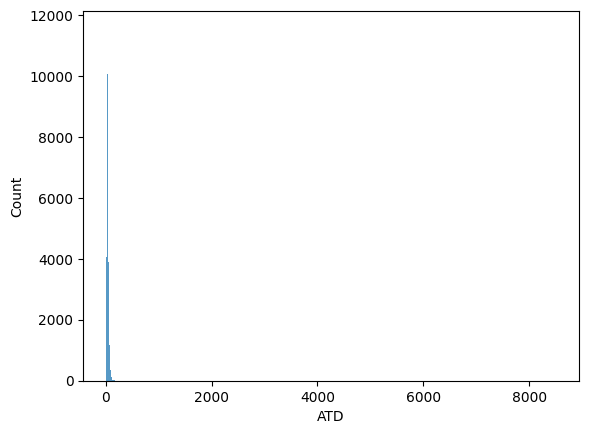

In [104]:
sns.histplot(df_clean["ATD"])

In [105]:
for q in [0.99, 0.98, 0.97, 0.95]:
    upper = df["ATD"].quantile(q)
    print(q, upper)

0.99 112.13333333333334
0.98 90.06666666666666
0.97 81.23333333333333
0.95 71.55


<Axes: xlabel='pickup_distance', ylabel='ATD'>

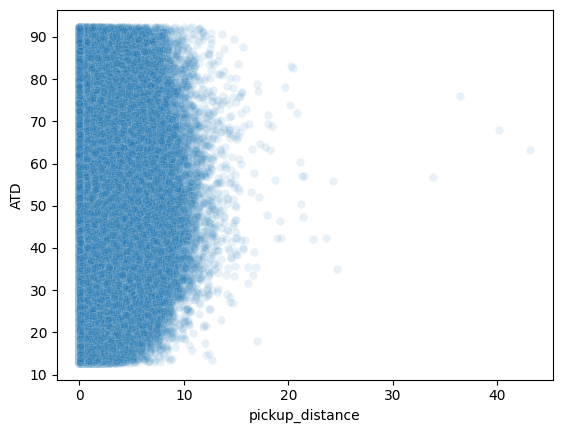

In [106]:
# El core vive en 25–50 min 
# hasta ~80–90 min (upper normal)

lower = df_clean["ATD"].quantile(0.02)
upper = df_clean["ATD"].quantile(0.98)

filtered_atd = df_clean[(df_clean["ATD"] >= lower) & (df_clean["ATD"] <= upper)]

sns.scatterplot(x=filtered_atd["pickup_distance"], y=filtered_atd["ATD"], alpha=0.1)

<Axes: xlabel='dropoff_distance', ylabel='ATD'>

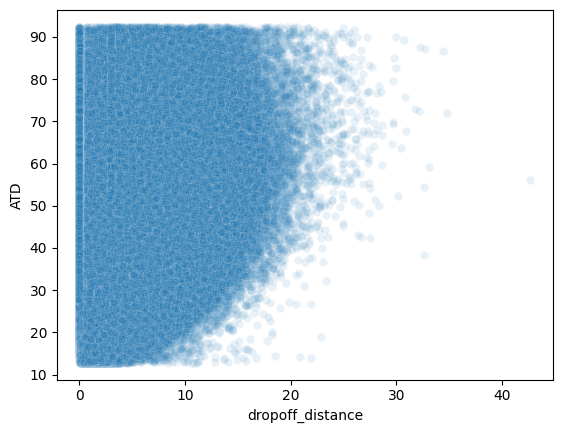

In [107]:
sns.scatterplot(x=filtered_atd["dropoff_distance"], y=filtered_atd["ATD"], alpha=0.1)

/var/folders/yd/tfd55g4x63d6mkkqlcscwgvr0000gn/T/ipykernel_48009/991905773.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_atd["hour"] = filtered_atd["eater_request_timestamp_local"].dt.hour


<Axes: xlabel='hour', ylabel='ATD'>

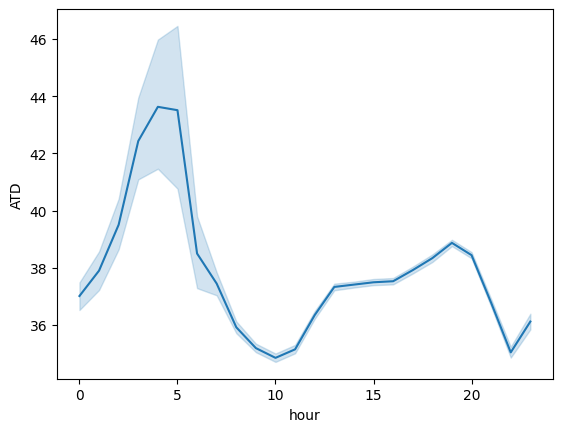

In [108]:
filtered_atd["hour"] = filtered_atd["eater_request_timestamp_local"].dt.hour

sns.lineplot(x=filtered_atd["hour"], y=filtered_atd["ATD"], estimator="mean")

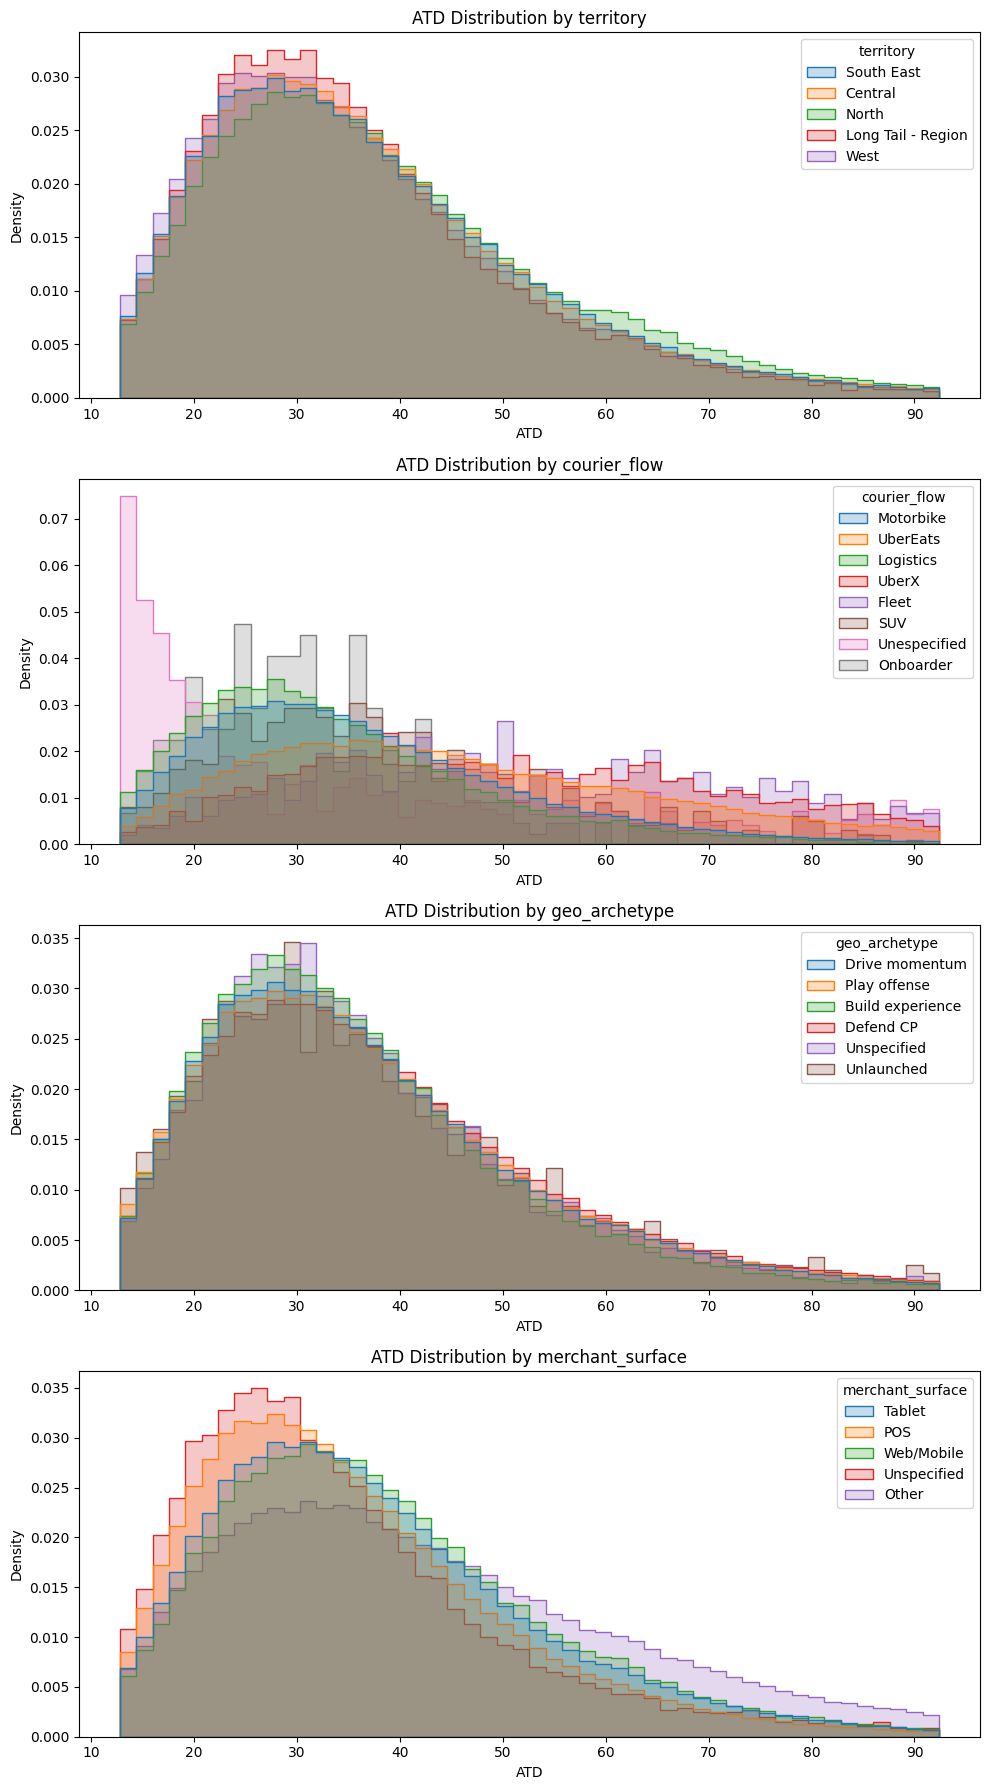

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------
# CONFIG
# -----------------------------
df_plot = filtered_atd.copy()

cat_cols = ["territory", "courier_flow", "geo_archetype", "merchant_surface"]

# -----------------------------
# 1. HISTOGRAMAS POR CATEGORÍA
# -----------------------------
fig, axes = plt.subplots(len(cat_cols), 1, figsize=(10, 18))

for i, col in enumerate(cat_cols):
    sns.histplot(
        data=df_plot,
        x="ATD",
        hue=col,
        bins=50,
        element="step",
        stat="density",
        common_norm=False,
        ax=axes[i]
    )
    axes[i].set_title(f"ATD Distribution by {col}")

plt.tight_layout()
plt.show()






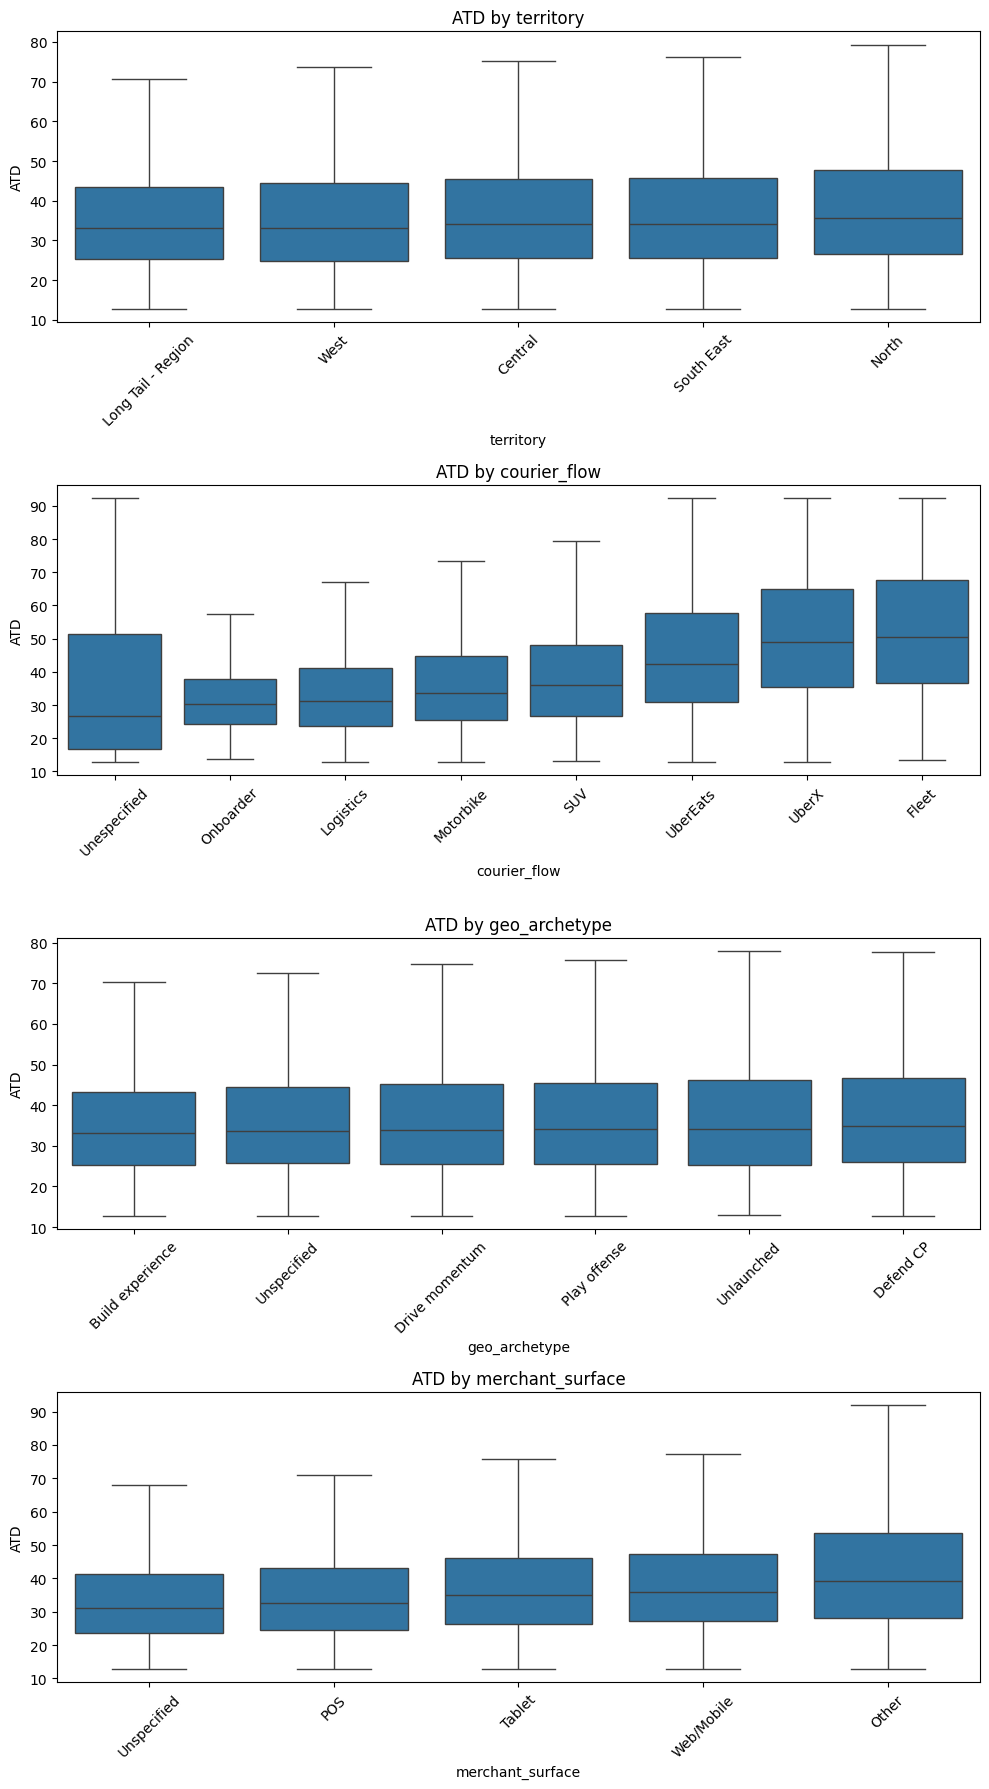

In [110]:
# -----------------------------
# 2. BOXPLOTS POR CATEGORÍA
# -----------------------------
fig, axes = plt.subplots(len(cat_cols), 1, figsize=(10, 18))

for i, col in enumerate(cat_cols):
    order = df_plot.groupby(col)["ATD"].median().sort_values().index
    
    sns.boxplot(
        data=df_plot,
        x=col,
        y="ATD",
        order=order,
        showfliers=False,
        ax=axes[i]
    )
    
    axes[i].set_title(f"ATD by {col}")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


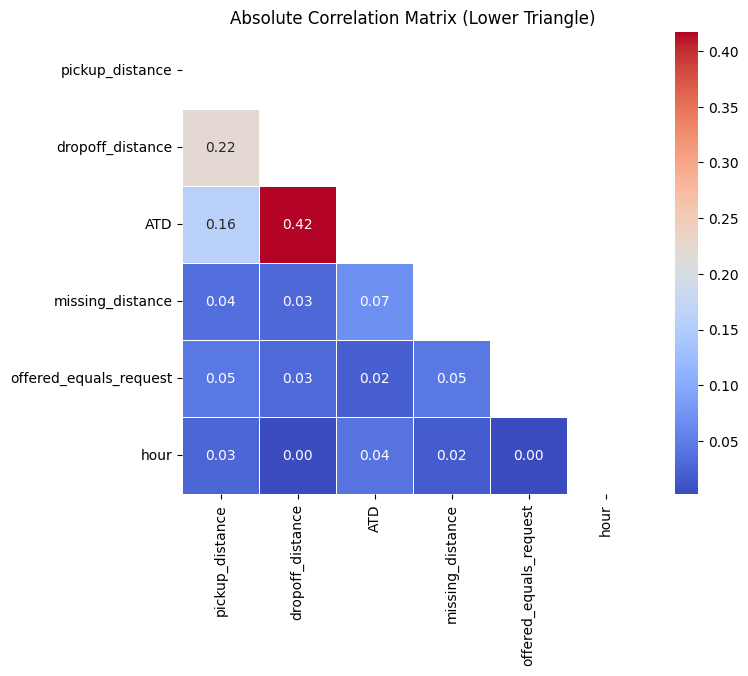

In [111]:
# -----------------------------
# CORRELACIÓN ABSOLUTA
# -----------------------------
numeric_cols = df_plot.select_dtypes(include=["float64", "int64"]).columns

corr = df_plot[numeric_cols].corr().abs()

# -----------------------------
# MÁSCARA (triángulo superior)
# -----------------------------
mask = np.triu(np.ones_like(corr, dtype=bool))

# -----------------------------
# PLOT
# -----------------------------
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("Absolute Correlation Matrix (Lower Triangle)")
plt.show()

In [112]:
final_df = df_plot.drop(columns=['hour'])

final_df.to_csv('df_clean.csv', index=False)